Data head:
   Time (s)  Drive Voltage (V)  Bias Voltage (V)  Resistor Voltage Drop (V)  \
0  0.561000               -4.0         -0.175597                  -3.824403   
1  0.766000               -3.8         -0.173223                  -3.626777   
2  0.852000               -3.6         -0.171830                  -3.428170   
3  0.960001               -3.4         -0.168803                  -3.231197   
4  1.071000               -3.2         -0.164143                  -3.035857   

   Current (A)  Raw AO0 (V)  Raw AI0 (V)  Raw AI1 (V)  
0    -0.001762         -4.0    -3.999491    -3.824403  
1    -0.001671         -3.8    -3.799251    -3.626777  
2    -0.001580         -3.6    -3.599665    -3.428170  
3    -0.001489         -3.4    -3.399751    -3.231197  
4    -0.001399         -3.2    -3.199512    -3.035857  

Column names:
Index(['Time (s)', 'Drive Voltage (V)', 'Bias Voltage (V)',
       'Resistor Voltage Drop (V)', 'Current (A)', 'Raw AO0 (V)',
       'Raw AI0 (V)', 'Raw AI1 (V)'],

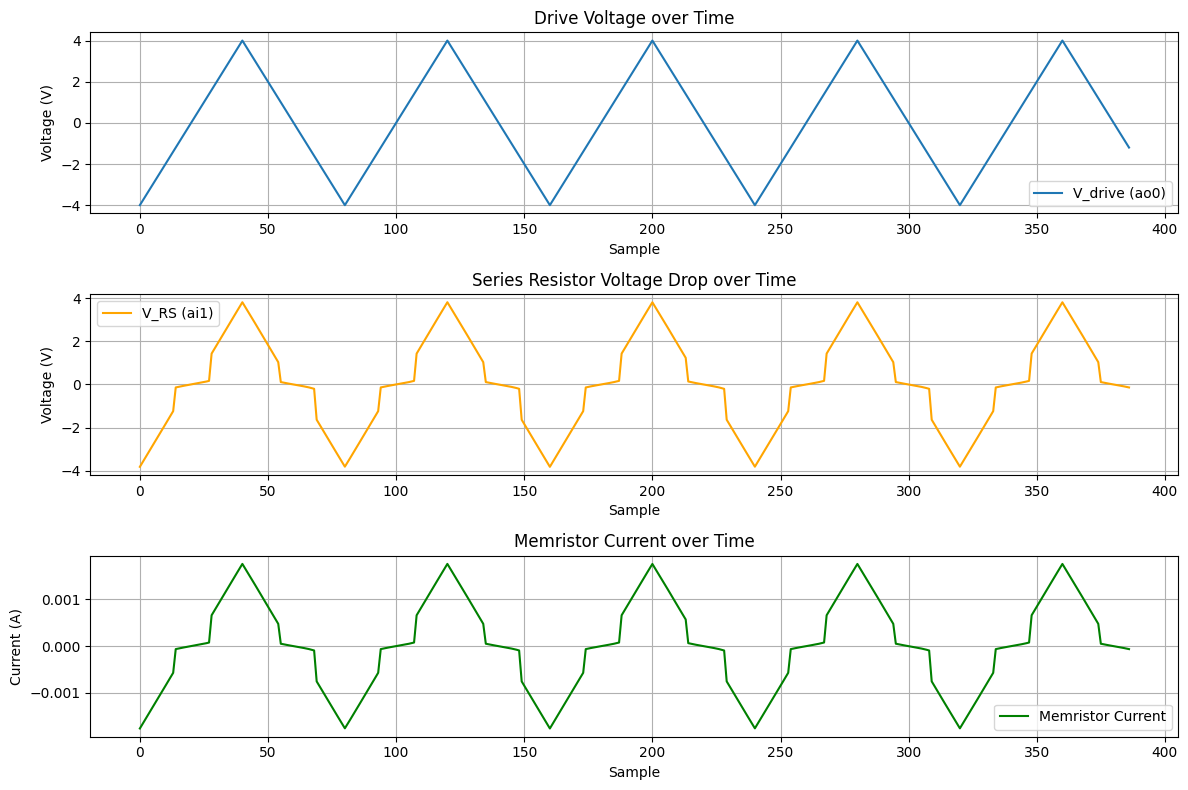

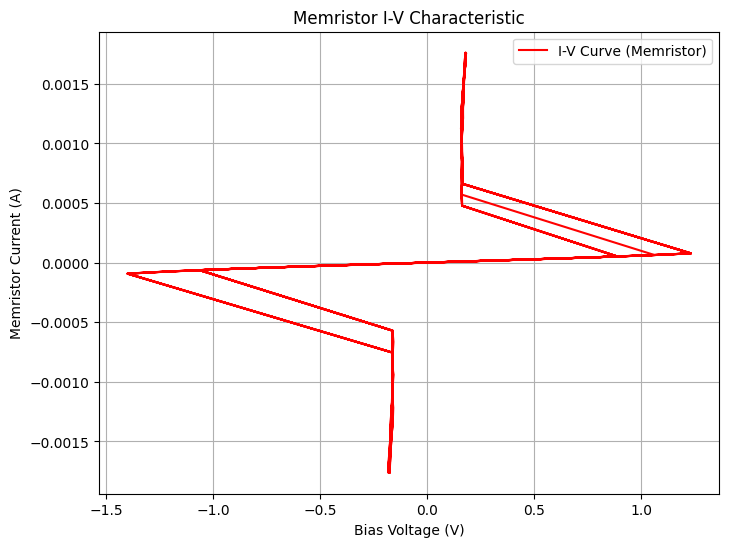

In [1]:
# Task 2: I-V curve

# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define the series resistance (RS) - USER INPUT REQUIRED
# This value is crucial for calculating the current and bias voltage.
# Please replace the placeholder with the actual value of your series resistor in Ohms.
RS = 2170  # Example value: 1 kOhm. Please update this with the correct value.

# File path for the data
file_path = 'task2_second'

# Read the tab-separated data
# Assuming the first row contains headers. If not, adjust header=None and manually assign column names.
df = pd.read_csv(file_path, sep='\t')

# Display the first few rows and column names to verify
print("Data head:")
print(df.head())
print("\nColumn names:")
print(df.columns)

# Extract relevant columns
# Assuming 'ai0', 'ai1', and 'ao0' are the column names as specified.
# Please verify these names from the print(df.columns) output and adjust if necessary.

try:
    Vdrive = df['Raw AO0 (V)'] # Corrected column name for drive voltage
    V_RS = df['Raw AI1 (V)']   # Corrected column name for series resistor voltage drop
    # ai0 is mentioned, but its role isn't explicitly defined for calculations yet. 
    # It might be another measured voltage or current if multiple channels are used.
    # For now, we focus on Vdrive and V_RS for current and bias voltage calculations.
except KeyError as e:
    print(f"Error: Missing expected column: {e}. Please check the 'out.txt' file and adjust column names if necessary.")
    exit()

# Calculate the current in the memristor
# I = V_RS / RS
I_memristor = V_RS / RS

# Calculate the bias voltage across the memristor
# Vbias = Vdrive - I * RS. This simplifies to Vbias = Vdrive - V_RS
Vbias = Vdrive - V_RS

# Add calculated values to the DataFrame
df['I_memristor'] = I_memristor
df['Vbias'] = Vbias

# Display calculated values
print("\nData with calculated values:")
print(df.head())

# Plotting the data
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(Vdrive, label='V_drive (ao0)')
plt.xlabel('Sample')
plt.ylabel('Voltage (V)')
plt.title('Drive Voltage over Time')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(V_RS, label='V_RS (ai1)', color='orange')
plt.xlabel('Sample')
plt.ylabel('Voltage (V)')
plt.title('Series Resistor Voltage Drop over Time')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(I_memristor, label='Memristor Current', color='green')
plt.xlabel('Sample')
plt.ylabel('Current (A)')
plt.title('Memristor Current over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(Vbias, I_memristor, label='I-V Curve (Memristor)', color='red')
plt.xlabel('Bias Voltage (V)')
plt.ylabel('Memristor Current (A)')
plt.title('Memristor I-V Characteristic')
plt.legend()
plt.grid(True)
plt.show()



In [2]:
# Calculate the slope of the I-V curve (dI/dVbias)
# Using numpy.gradient for numerical differentiation
slope_iv_curve = np.gradient(df['I_memristor'], df['Vbias'])

# Calculate the inverse of the slope (dVbias/dI)
# This represents the differential resistance
inverse_slope_iv_curve = 1 / slope_iv_curve

print("\nSlope of the I-V curve (dI/dVbias) - first 5 values:")
print(slope_iv_curve[:5])

print("\nInverse of the slope (Differential Resistance - dVbias/dI) - first 5 values:")
print(inverse_slope_iv_curve[:5])

# You can also plot these if needed

# plt.figure(figsize=(10, 6))
# plt.plot(df['Vbias'], slope_iv_curve, label='dI/dVbias')
# plt.xlabel('Bias Voltage (V)')
# plt.ylabel('Slope (A/V)')

# plt.title('Slope of I-V Curve')
# plt.grid(True)
# plt.legend()
# plt.show()

# plt.figure(figsize=(10, 6))
# plt.plot(df['Vbias'], inverse_slope_iv_curve, label='Differential Resistance', color='purple')
# plt.xlabel('Bias Voltage (V)')
# plt.ylabel('Resistance (Ohms)')
# plt.title('Differential Resistance of Memristor')
# plt.grid(True)
# plt.legend()
# plt.show()




Slope of the I-V curve (dI/dVbias) - first 5 values:
[0.03837007 0.05557502 0.05442573 0.02578657 0.02225945]

Inverse of the slope (Differential Resistance - dVbias/dI) - first 5 values:
[26.06198114 17.99369474 18.37366398 38.77987233 44.92473767]


In [ ]:
# Perform a polynomial fit for the I-V curve (I_memristor vs Vbias)
# You can change the degree of the polynomial as needed.
degree = 1 # Starting with a linear fit. Change to 2, 3, etc., for higher-order polynomial fits.

coefficients_iv_curve = np.polyfit(df['Vbias'], df['I_memristor'], degree)

print(f"\nPolynomial fit coefficients for I-V curve (degree={degree}):")
# Print coefficients based on the degree
if degree == 1:
    print(f"Resistance: {(1/coefficients_iv_curve[0]):.4} Ohm")
else:
    print(f"  Coefficients: {coefficients_iv_curve}")

# To get the fitted line for plotting:
fitted_iv_curve = np.polyval(coefficients_iv_curve, df['Vbias'])

# Plotting the I-V curve with the fit
plt.figure(figsize=(8, 6))
plt.plot(df['Vbias'], df['I_memristor'], label='Measured I-V Curve', marker='o', linestyle='-', markersize=4, color='red')
plt.plot(df['Vbias'], fitted_iv_curve, label=f'Polynomial Fit (degree={degree})', color='blue', linestyle='--')
plt.xlabel('Bias Voltage (V)')
plt.ylabel('Memristor Current (A)')
plt.title('Memristor I-V Characteristic with Polynomial Fit')
plt.grid(True)
plt.legend()
plt.show()



In [4]:
# Task 3: R(t) analysis
# Task 3: R(t) analysis -- Plot resistance of the memristor as a function of time
# Assuming your dataframe `df` has columns 'Time (s)' and 'Sample Resistance (Ohm)'

plt.figure(figsize=(10, 6))
plt.plot(df['Time (s)'], df['Sample Resistance (Ohm)'], label='R(t)', color='green')
plt.xlabel('Time (s)')
plt.ylabel('Sample Resistance (Ohm)')
plt.title('Time-Dependent Resistance of Memristor')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


KeyError: 'Sample Resistance (Ohm)'

<Figure size 1000x600 with 0 Axes>

In [ ]:
# Task 4: Relaxation time analysis (AI1 = V_trans)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Configure input ---
# Set your measurement file path here (tab-separated as saved by the C# app)
meas_path = 'task4.txt'
Z0 = 50.0  # characteristic impedance (ohm)

# --- Load data ---
df = pd.read_csv(meas_path, sep='\t')

# Expect these columns in the unified log (verify headers if needed)
time = df['Time (s)'].to_numpy()
VIN = df['Raw AO0 (V)'].to_numpy()         # Use Raw AO0 (V) as VIN(t)
VTRANS = df['Raw AI1 (V)'].to_numpy()      # Use Raw AI1 (V) as VTRANS(t)o

# --- Guard: avoid division by zero ---
mask = VTRANS != 0
if not np.any(mask):
    raise ValueError('All VTRANS values are zero; cannot compute RM. Check wiring/columns.')

time = time[mask]
VIN = VIN[mask]
VTRANS = VTRANS[mask]

# --- Compute RM(t) using Eq. III.4.2 ---
# RM(t) = 2*Z0 * (VIN/VTRANS - 1)
RM = 2.0 * Z0 * (VIN / VTRANS - 1.0)

# --- Plot RM(t) ---
plt.figure(figsize=(10,5))
plt.plot(time, RM, '-', lw=1)
plt.xlabel('Time (s)')
plt.ylabel('RM(t) [Ohm]')
plt.title('VO2 Memristor Relaxation (AI1 as VTRANS)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [ ]:

# Simple heuristic: time to reach 90% between RLRS(min) and RHRS(max)
RLRS = np.nanmin(RM)
RHRS = np.nanmax(RM)
target = RLRS + 0.9 * (RHRS - RLRS)

idx = np.where(RM >= target)[0]
if idx.size:
    reset_time_s = time[idx[0]] - time[0]
    print(f"Estimated reset time to 90% HRS: {reset_time_s*1e6:.2f} µs")
else:
    print('No clear relaxation crossing 90% threshold detected. Consider adjusting the pulse/readout window or threshold.')


In [ ]:
# Task 5: VO2 Oscillator evaluation (current via 50 Ω shunt)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- Configure input ---
# Oscilloscope-exported CSV with time and channels (adjust names as needed)
# Expected columns examples: 'Time(s)', 'CH1(V)', 'CH2(V)' or Vendor-specific headers
osc_path = 'YOUR_OSCILLOSCOPE_CSV.csv'  # TODO: change to your file name
TIME_COL = 'Time(s)'                     # change if needed
VTRANS_COL = 'CH1(V)'                    # measured at shunt (osc input)
VIN_COL = 'CH2(V)'                       # reference drive from AWG

Z0 = 50.0          # shunt/termination (ohm)
min_prom = 0.05     # min prominence for peak detection (V); adjust per signal level

# --- Load osc data ---
df_osc = pd.read_csv(osc_path)
if TIME_COL not in df_osc.columns:
    raise ValueError(f'Missing time column {TIME_COL!r} in {osc_path}. Found: {list(df_osc.columns)[:6]} ...')
if VTRANS_COL not in df_osc.columns:
    raise ValueError(f'Missing VTRANS column {VTRANS_COL!r}.')
if VIN_COL not in df_osc.columns:
    print(f'Warning: VIN column {VIN_COL!r} not found. Continuing without VIN.')

# Extract arrays
T = df_osc[TIME_COL].to_numpy()
Vtrans = df_osc[VTRANS_COL].to_numpy()
Vin = df_osc[VIN_COL].to_numpy() if VIN_COL in df_osc.columns else None

# Compute current through the 50 Ω shunt: I = Vtrans / Z0
I = Vtrans / Z0  # Ampere

# Basic plots
fig, ax = plt.subplots(2 if Vin is not None else 1, 1, figsize=(10, 6), sharex=True)
if Vin is not None:
    ax0 = ax[0]
    ax1 = ax[1]
    ax0.plot(T, Vin, lw=1)
    ax0.set_ylabel('VIN (V)')
    ax0.grid(True, alpha=0.3)
    ax0.set_title('Burst drive and transmitted current')
    ax1.plot(T, I, lw=1)
    ax1.set_ylabel('I (A)')
    ax1.set_xlabel('Time (s)')
    ax1.grid(True, alpha=0.3)
else:
    ax.plot(T, I, lw=1)
    ax.set_ylabel('I (A)')
    ax.set_xlabel('Time (s)')
    ax.grid(True, alpha=0.3)
    ax.set_title('Transmitted current (via 50 Ω shunt)')
plt.tight_layout()
plt.show()

# --- Estimate oscillation frequency ---
# Select a window where oscillations are present (auto: central 50% as a heuristic)
N = len(T)
if N < 10:
    raise ValueError('Too few samples to estimate frequency.')
lo = int(0.25 * N)
hi = int(0.75 * N)
Tw = T[lo:hi]
Iw = I[lo:hi]

# Peak-based period estimate
# Use prominence to avoid noise-triggered peaks; adjust min_prom as needed
peaks, _ = find_peaks(Iw, prominence=min_prom)
if peaks.size >= 2:
    peak_times = Tw[peaks]
    periods = np.diff(peak_times)
    if periods.size:
        f_mean = 1.0 / np.mean(periods)
        f_std = np.std(1.0 / periods) if periods.size > 1 else 0.0
        print(f"Estimated oscillation frequency: {f_mean:.3e} Hz (±{f_std:.2e})")
    else:
        print('Not enough peaks to estimate period. Increase burst length or adjust prominence.')
else:
    # Fallback: FFT-based estimate
    dt = np.median(np.diff(Tw))
    if dt <= 0:
        print('Non-positive dt; cannot run FFT fallback.')
    else:
        Iw_detr = Iw - np.mean(Iw)
        Nw = len(Iw_detr)
        # next power of two for speed
        Nfft = 1 << (Nw - 1).bit_length()
        freqs = np.fft.rfftfreq(Nfft, d=dt)
        spec = np.abs(np.fft.rfft(Iw_detr, n=Nfft))
        if freqs.size > 1:
            # Ignore DC
            idx = np.argmax(spec[1:]) + 1
            print(f"Estimated oscillation frequency (FFT): {freqs[idx]:.3e} Hz")
        else:
            print('Unable to estimate frequency; check data window and signal levels.')

# --- Notes for series sweeps ---
# To study dependence on V0 and C, repeat acquisitions while varying drive amplitude
# and the parallel capacitance C. Save each CSV and aggregate their frequency estimates
# into a table for plotting f vs V0 and f vs C.



